In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
import warnings
warnings.filterwarnings('ignore')

## 1. Load and Preprocess Data

In [2]:
# Load dataset
df = pd.read_csv('archive/NIFTY50_all.csv')
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')

# Use only Close prices from one stock (RELIANCE) for simplicity
stock_data = df[df['Symbol'] == 'RELIANCE'][['Date', 'Close']].dropna()
print(f"Data shape: {stock_data.shape}")
print(stock_data.head())

Data shape: (5306, 2)
             Date   Close
166253 2000-01-03  251.70
166254 2000-01-04  271.85
166255 2000-01-05  282.50
166256 2000-01-06  294.35
166257 2000-01-07  314.55


In [3]:
# Normalize data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(stock_data['Close'].values.reshape(-1, 1))
print(f"Normalized data shape: {scaled_data.shape}")

Normalized data shape: (5306, 1)


In [4]:
# Create time windows (60 days to predict next day)
def create_sequences(data, window_size=60):
    X, y = [], []
    for i in range(window_size, len(data)):
        X.append(data[i-window_size:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

window_size = 60
X, y = create_sequences(scaled_data, window_size)

# Train-test split (80-20)
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Reshape for LSTM [samples, timesteps, features]
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

X_train shape: (4196, 60, 1), y_train shape: (4196,)
X_test shape: (1050, 60, 1), y_test shape: (1050,)


## 2. Build LSTM Model with Dropout

In [5]:
def build_lstm_model(learning_rate=0.001):
    model = Sequential([
        LSTM(50, return_sequences=True, input_shape=(window_size, 1)),
        Dropout(0.2),  # Dropout to prevent overfitting
        LSTM(50, return_sequences=False),
        Dropout(0.2),
        Dense(25),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss='mean_squared_error')
    return model

## 3. Train with Different Learning Rates and Evaluate

In [6]:
# Experiment with different learning rates
learning_rates = [0.01, 0.001, 0.0001]
results = {}

for lr in learning_rates:
    print(f"\n{'='*50}")
    print(f"Training with Learning Rate: {lr}")
    print('='*50)
    
    model = build_lstm_model(learning_rate=lr)
    history = model.fit(X_train, y_train, epochs=20, batch_size=32, 
                       validation_split=0.1, verbose=0)
    
    # Predictions
    predictions = model.predict(X_test, verbose=0)
    
    # Inverse transform to get actual prices
    predictions = scaler.inverse_transform(predictions)
    y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))
    
    # Calculate RMSE
    rmse = np.sqrt(mean_squared_error(y_test_actual, predictions))
    
    results[lr] = {
        'model': model,
        'predictions': predictions,
        'rmse': rmse,
        'history': history
    }
    
    print(f"RMSE: {rmse:.2f}")

# Display RMSE comparison
print("\n" + "="*50)
print("RMSE Comparison:")
print("="*50)
for lr, result in results.items():
    print(f"Learning Rate {lr}: RMSE = {result['rmse']:.2f}")


Training with Learning Rate: 0.01


2025-12-01 10:47:31.499171: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2025-12-01 10:47:31.499208: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2025-12-01 10:47:31.499211: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2025-12-01 10:47:31.499351: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-12-01 10:47:31.499359: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
2025-12-01 10:47:32.515849: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.
2025-12-01 10:47:32.515849: I t

RMSE: 43.03

Training with Learning Rate: 0.001
RMSE: 55.85

Training with Learning Rate: 0.0001
RMSE: 55.85

Training with Learning Rate: 0.0001
RMSE: 84.86

RMSE Comparison:
Learning Rate 0.01: RMSE = 43.03
Learning Rate 0.001: RMSE = 55.85
Learning Rate 0.0001: RMSE = 84.86
RMSE: 84.86

RMSE Comparison:
Learning Rate 0.01: RMSE = 43.03
Learning Rate 0.001: RMSE = 55.85
Learning Rate 0.0001: RMSE = 84.86


## 4. Plot Actual vs Predicted Prices

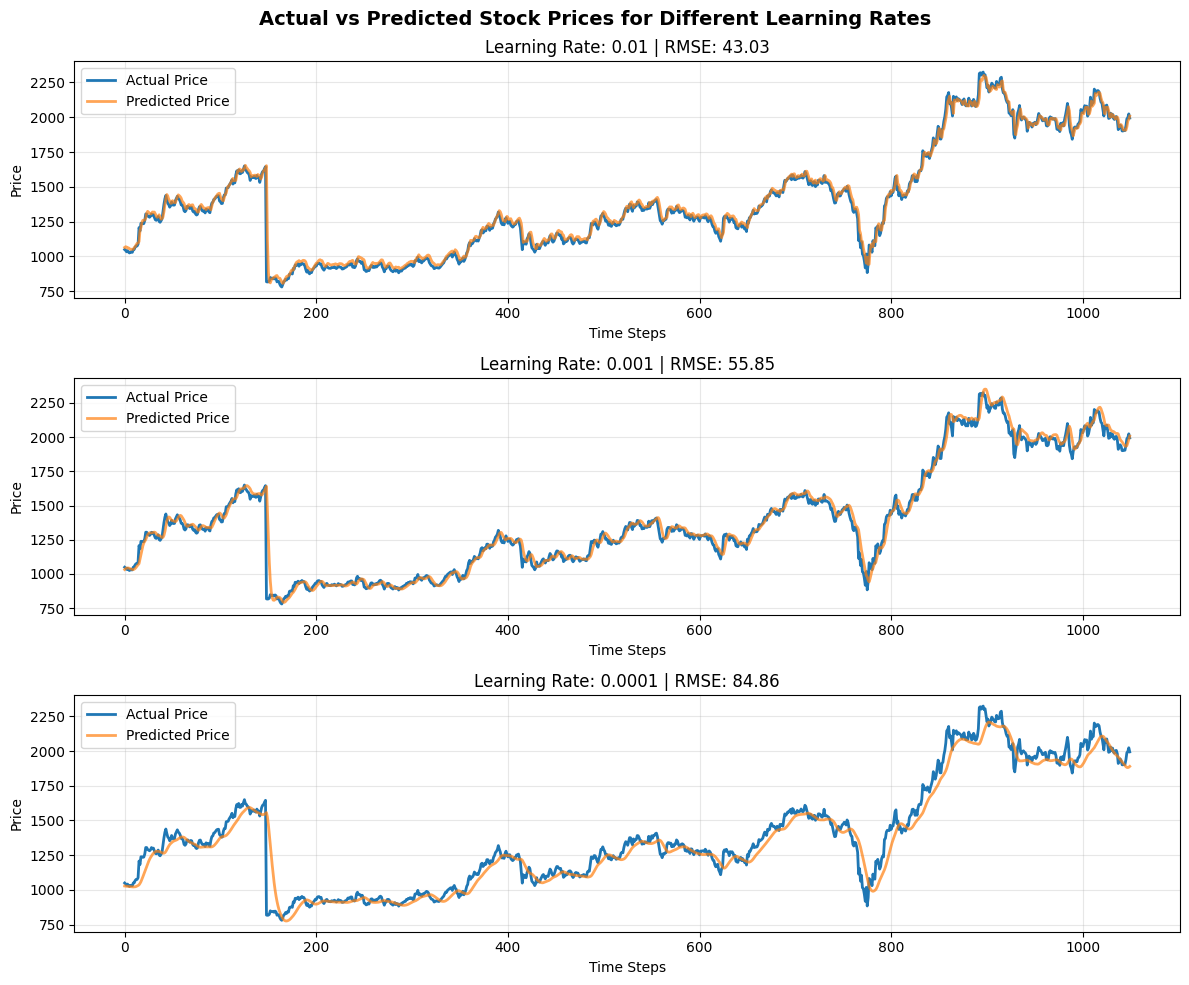

In [7]:
# Plot for all learning rates
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

fig, axes = plt.subplots(3, 1, figsize=(12, 10))
fig.suptitle('Actual vs Predicted Stock Prices for Different Learning Rates', fontsize=14, fontweight='bold')

for idx, lr in enumerate(learning_rates):
    ax = axes[idx]
    predictions = results[lr]['predictions']
    rmse = results[lr]['rmse']
    
    ax.plot(y_test_actual, label='Actual Price', linewidth=2)
    ax.plot(predictions, label='Predicted Price', linewidth=2, alpha=0.7)
    ax.set_title(f'Learning Rate: {lr} | RMSE: {rmse:.2f}')
    ax.set_xlabel('Time Steps')
    ax.set_ylabel('Price')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Summary
- **Preprocessing**: Normalized data and created 60-day time windows
- **Model**: 2-layer LSTM with Dropout (0.2) for regularization
- **Learning Rates**: Tested 0.01, 0.001, 0.0001
- **Evaluation**: RMSE metric used
- **Visualization**: Actual vs Predicted prices plotted